In [1]:
import xskillscore as xs
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
from scipy.spatial.distance import cdist
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
import matplotlib.colorbar as colorbar
import seaborn as sns

In [2]:
# ---------------------------------------
# paths
# ---------------------------------------
misfits_final = xr.open_dataset("./scores/misfits.nc")
df = pd.read_csv('../proccessing_ensemble/lhs_np15_ns3000_values.txt', sep='\s+')
ds = df.to_xarray()
ds1 = ds.rename({'index': 'sim'})


<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3427772/174525343.py:5: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('../proccessing_ensemble/lhs_np15_ns3000_values.txt', sep='\s+')


In [3]:
# scores following pollard
def calc_M_prima (sc, var):
    M = sc[var]/(sc[var].median())
    return M.values
def calc_S (sc, var):
    M = sc[var]/(sc[var].median())
    S = np.exp(-M)
    return S.values
data_vars = ['M_pd1', 'M_pd2', 'M_pd3', 'M_pd4', 'M_pt1g','M_pt1n', 'M_pt1d', 'M_pt2_chi2', 'M_pt3'] 

S_H_ice = calc_S(misfits_final,'M_pd1')
S_ice_cover = calc_S(misfits_final,'M_pd2')
S_z_bed = calc_S(misfits_final,'M_pd3')
S_uxy = calc_S(misfits_final,'M_pd4')
S_grip = calc_S(misfits_final,'M_pt1g')
S_ngrip = calc_S(misfits_final,'M_pt1n')
S_dye3 = calc_S(misfits_final,'M_pt1d')
S_camp = calc_S(misfits_final,'M_pt1c')
S_isocr = calc_S(misfits_final,'M_pt2_chi2')
S_lgm = calc_S(misfits_final,'M_pt3')

sc_total = []
for var in data_vars:
    M = calc_M_prima(misfits_final,var)
    sc_total.append(M)
sc_total = np.array(sc_total)
S = np.exp(-sc_total.sum(0))

In [4]:
S = np.exp(-sc_total.sum(0))

int(S.argmax())

2572

In [8]:
S[S.argmax()]

np.float64(0.005762479983917195)

In [5]:
ds_S = xr.Dataset(
    data_vars={"S": (("sim"), S),
        "S_H_ice": (("sim"), S_H_ice),
        "S_ice_cover": (("sim"), S_ice_cover),
        "S_z_bed": (("sim"), S_z_bed),
        "S_uxy": (("sim"), S_uxy),
        # "S_camp": (("sim"), S_camp),
        "S_grip": (("sim"), S_grip),
        "S_ngrip": (("sim"), S_ngrip),
        "S_dye3": (("sim"), S_dye3),
        "S_isocr": (("sim"), S_isocr),
        "S_lgm": (("sim"), S_lgm),   
    },
    coords={
        "sim": misfits_final.sim
    })
ds_S.to_netcdf("./scores/scores_final.nc")


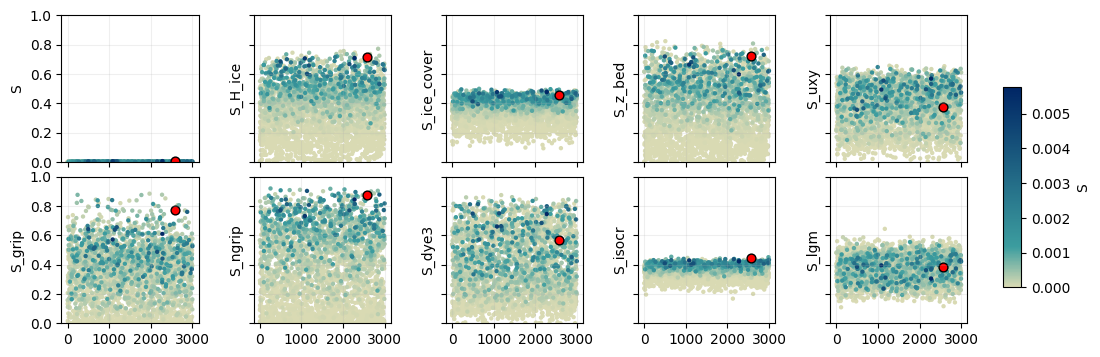

<Figure size 640x480 with 0 Axes>

In [6]:
ds_S = xr.open_dataset("./scores/scores_final.nc")
n_best=int(ds_S.S.argmax())
ds_S2 = ds_S.sortby('S')
variables = ["S", "S_H_ice", "S_ice_cover", "S_z_bed", "S_uxy", "S_grip", "S_ngrip","S_dye3", "S_isocr", "S_lgm"]

n_vars = len(variables)
n = ds_S.S.argmax().item()
fig, axs = plt.subplots(2, 5, figsize=(12,4), sharex=True, sharey=True)
axs = axs.flatten()
colors = ["#D9DAB3", "#3C9D9F", "#002665"]
nodes = [0, 0.2, 1.0]
custom_cmap = LinearSegmentedColormap.from_list("custom_warm", list(zip(nodes, colors)))

for i, var in enumerate(variables):
    n_local= ds_S[var].argmax().item()
    ax = axs[i]
    sc=ax.scatter(ds_S2.sim, ds_S2[var], s=10, alpha=1, c=(ds_S2.S), cmap=custom_cmap, edgecolor='none')
    # ax.scatter(ds_S.sim.sel(sim=n_local), ds_S[var].sel(sim=n_local), s=40, alpha=1, color='blue',edgecolor='black')
    # ax.scatter(ds_S.sim.sel(sim=n), ds_S[var].sel(sim=n), s=40, alpha=1, color='red',edgecolor='black')
    ax.scatter(ds_S.sim.sel(sim=n_best), ds_S[var].sel(sim=2572), s=40, alpha=1, color='red',edgecolor='black')

    ax.set_ylabel(f'{var}')
    ax.grid(True, alpha=0.2)
    ax.set_xticks(np.arange(0, 3001, 1000))
    ax.set_ylim(0,1)
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.subplots_adjust(right=0.88, hspace=0.1, wspace=0.4)
cbar_ax = fig.add_axes([0.91, 0.2, 0.015, 0.5])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('S')
plt.show()
plt.savefig("./figs_scores/score_components.png", dpi=300)